# Wind Farm Layout Optimization as a Nonlinear Program (NLP)

This notebook formulates and solves a simplified **wind farm layout optimization** problem using **Pyomo** and **IPOPT**.

The locations of the wind turbines are continuous decision variables. The model contains three important nonlinearities:

1. **Minimum-distance constraints** between turbines;
2. A **static nonlinear wake model** that reduces downstream wind speed;
3. The cubic relationship between wind speed and generated power.

For simplicity, wind is assumed to blow steadily from west to east, i.e. in the positive $x$-direction. Turbines are indexed in downstream order, so turbine $j<i$ may affect turbine $i$.

## 1. Model formulation

### Decision variables

For each turbine $i\in\mathcal{I}$:

- $x_i$ = $x$-coordinate of turbine $i$ [m]
- $y_i$ = $y$-coordinate of turbine $i$ [m]
- $v_i$ = effective wind speed at turbine $i$ [m/s]

### Fixed parameters

- $N$ = number of wind turbines
- $L_x$ = wind-farm length in the $x$-direction [m]
- $L_y$ = wind-farm width in the $y$-direction [m]
- $D_{\min}$ = minimum allowable distance between turbines [m]
- $v_0$ = free-stream wind speed [m/s]
- $a$ = maximum wake-deficit coefficient
- $k_x$ = downstream wake-recovery coefficient [1/m]
- $\sigma_y$ = lateral wake-width parameter [m]
- $K_P$ = coefficient in the simplified power model
- $\epsilon$ = minimum separation in the $x$-direction between consecutive indexed turbines [m]

## 2. Objective function

The generated power of turbine $i$ is approximated by

$$ P_i = K_P v_i^3. $$

The objective is to maximize total wind-farm power:

$$ \max \sum_{i\in\mathcal{I}} K_P v_i^3 $$

The cubic power expression is nonlinear.

## 3. Constraints

### Site-boundary constraints

Every wind turbine must remain within the available rectangular site:

$$ 0\leq x_i\leq L_x, $$

$$ 0\leq y_i\leq L_y. $$

These are implemented directly as bounds on the Pyomo decision variables.

### Minimum-distance constraints

For every pair of turbines $i<j$,

$$ (x_i-x_j)^2 + (y_i-y_j)^2 \geq D_{\min}^2 $$

This prevents turbines from being placed too close together. The squared form avoids introducing a square-root function.

### Downstream-ordering constraints

Because the simplified wake model assumes the turbine index follows the wind direction,

$$ x_{i+1} \geq x_i + \epsilon $$

for $i=1,\ldots,N-1$.

### Static nonlinear wake model

For an upstream turbine $j$ and downstream turbine $i$, define the wake-induced wind-speed deficit as

$$ \delta v_{ji} = a v_0 \exp\left[-k_x(x_i-x_j)\right] \exp\left[-\frac{(y_i-y_j)^2}{2\sigma_y^2}\right]. $$

Thus, for the first turbine, $v_1=v_0, $, while for downstream turbines,

$$ v_i = v_0 - \sum_{j<i}\delta v_{ji} $$

or equivalently,

$$ v_i = v_0 - \sum_{j<i} a v_0 \exp\left[-k_x(x_i-x_j)\right] \exp\left[-\frac{(y_i-y_j)^2}{2\sigma_y^2}\right].$$

This is a **static** wake model: it gives the steady wind-speed field for a fixed wind direction and does not model transient wake dynamics.

### Circular Siting Region
For this example, what if the land allowable for placing wind turbines is only circular with center $(L_x/2, L_y/2)$ and radius $R$?

$$ (x_i - L_x/2)^2 + (y_i - L_y/2)^2 \leq R^2 $$

## Import packages

IPOPT is used because this is a continuous nonlinear optimization problem. Make sure IPOPT is installed and available to Pyomo.

In [1]:
import pyomo.environ as pyo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Fixed data and model parameters

The values below are illustrative and can be modified for experiments.

In [2]:
# Number of turbines
N = 5

# Farm dimensions [m]
Lx = 2000.0
Ly = 1000.0

# Minimum center-to-center turbine separation [m]
Dmin = 300.0

# Free-stream wind speed [m/s]
v0 = 10.0

# Static wake-model parameters
a = 0.25
kx = 0.002       # 1/m
sigma_y = 150.0  # m

# Simplified power coefficient: P = Kp * v^3
# Here the resulting power can be interpreted in arbitrary power units.
Kp = 0.002

# Minimum downstream ordering difference [m]
epsilon = 20.0

# Circular siting region restriction
R = 400
xc = Lx / 2
yc = Ly / 2

## Build the Pyomo NLP model

The turbine coordinates and effective wind speeds are optimized simultaneously.

In [3]:
model = pyo.ConcreteModel()

# Turbine index set
model.I = pyo.RangeSet(1, N)

# Decision variables
model.x = pyo.Var(model.I, bounds=(0.0, Lx))
model.y = pyo.Var(model.I, bounds=(0.0, Ly))
model.v = pyo.Var(model.I, bounds=(1.0, v0))

# ------------------------------------------------------------
# Initial guesses
# ------------------------------------------------------------
# A reasonable initial layout is important for a nonconvex NLP.
for i in model.I:
    model.x[i].value = 200.0 + (i - 1) * 350.0
    model.y[i].value = 300.0 if i % 2 == 1 else 700.0
    model.v[i].value = 0.9 * v0

# ------------------------------------------------------------
# Minimum-distance constraints
# ------------------------------------------------------------
def minimum_distance_rule(model, i, j):
    if i >= j:
        return pyo.Constraint.Skip

    return (model.x[i] - model.x[j])**2 + (model.y[i] - model.y[j])**2 >= Dmin**2

model.minimum_distance = pyo.Constraint(
    model.I, model.I, rule=minimum_distance_rule
)

# ------------------------------------------------------------
# Downstream-ordering constraints
# ------------------------------------------------------------
def ordering_rule(model, i):
    if i == N:
        return pyo.Constraint.Skip

    return model.x[i + 1] >= model.x[i] + epsilon

model.ordering = pyo.Constraint(model.I, rule=ordering_rule)

# ------------------------------------------------------------
# Static nonlinear wake constraints
# ------------------------------------------------------------
def wind_speed_rule(model, i):
    if i == 1:
        return model.v[i] == v0

    total_wake_deficit = sum(
        a * v0 * pyo.exp(-kx * (model.x[i] - model.x[j]))
        * pyo.exp(-(model.y[i] - model.y[j])**2 / (2.0 * sigma_y**2))
        for j in range(1, i)
    )

    return model.v[i] == v0 - total_wake_deficit

model.wind_speed = pyo.Constraint(model.I, rule=wind_speed_rule)

# ============================================================
# CIRCULAR SITING REGION
# ============================================================
def circular_region_rule(model, i):
    return (model.x[i] - xc)**2 + (model.y[i] - yc)**2 <= R**2

model.circular_region = pyo.Constraint(model.I, rule=circular_region_rule)

# ------------------------------------------------------------
# Objective: maximize total wind-farm power
# ------------------------------------------------------------
def objective_rule(model):
    return sum(Kp * model.v[i]**3 for i in model.I)

model.objective = pyo.Objective(
    rule=objective_rule,
    sense=pyo.maximize
)

## Solve the NLP using IPOPT

Because the model is nonconvex, IPOPT generally returns a **local optimum**. Different initial turbine locations can therefore produce different optimized layouts.

In [4]:
solver = pyo.SolverFactory("ipopt")
results = solver.solve(model, tee=True)

print("Solver status:", results.solver.status)
print("Termination condition:", results.solver.termination_condition)

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:       33
Number of nonzeros in inequality constraint Jacobian.:       58
Number of nonzeros in Lagrangian Hessian.............:       60

Total number of variables............................:       15
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       15
                     variables with only upper bounds:        0
Total number of equality constraints.................:        5
Total number

## Store the optimized results in a Pandas DataFrame

The DataFrame can be reused later for additional analysis and plotting.

In [5]:
results_data = []

for i in model.I:
    x_i = pyo.value(model.x[i])
    y_i = pyo.value(model.y[i])
    v_i = pyo.value(model.v[i])
    P_i = Kp * v_i**3

    results_data.append({
        "Turbine": i,
        "x (m)": x_i,
        "y (m)": y_i,
        "Wind Speed (m/s)": v_i,
        "Power": P_i,
    })

df = pd.DataFrame(results_data)

display(df.round(4))

print(f"Total wind-farm power = {df['Power'].sum():.4f}")

,Turbine,x (m),y (m),Wind Speed (m/s),Power
0,1,633.8865,338.8761,10.0000,2.0000
1,2,653.8865,700.5130,9.8687,1.9222
2,3,1053.4911,103.5928,9.6839,1.8163
3,4,1073.4913,893.1908,9.5255,1.7286
4,5,1399.9961,501.7546,9.3867,1.6541


Total wind-farm power = 9.1212


## Check pairwise turbine distances

This is useful for confirming that the optimized layout satisfies the minimum-distance requirement.

In [6]:
pairwise_distances = []

for i in range(N):
    for j in range(i + 1, N):
        dx = df.loc[i, "x (m)"] - df.loc[j, "x (m)"]
        dy = df.loc[i, "y (m)"] - df.loc[j, "y (m)"]
        distance = np.sqrt(dx**2 + dy**2)

        pairwise_distances.append({
            "Turbine i": int(df.loc[i, "Turbine"]),
            "Turbine j": int(df.loc[j, "Turbine"]),
            "Distance (m)": distance,
        })

df_distance = pd.DataFrame(pairwise_distances)
display(df_distance.round(2))

print(
    "Minimum optimized pairwise distance = "
    f"{df_distance['Distance (m)'].min():.2f} m"
)

,Turbine i,Turbine j,Distance (m)
0,1,2,362.19
1,1,3,481.07
2,1,4,707.47
3,1,5,783.23
4,2,3,718.33
5,2,4,461.73
6,2,5,772.13
7,3,4,789.85
8,3,5,527.82
9,4,5,509.73


Minimum optimized pairwise distance = 362.19 m


## Plot the optimized layout together with the nonlinear wake contour

The contour below evaluates the **same static nonlinear wake expression** used by the optimization model on a dense spatial grid.

For visualization, each turbine contributes a wake only at points downstream of it. At a grid point $(x,y)$, the total wind-speed deficit is approximated as the sum of the individual turbine deficits:

$$ \Delta v(x,y) = \sum_{j:\,x>x_j} a v_0 \exp[-k_x(x-x_j)] \exp\left[-\frac{(y-y_j)^2}{2\sigma_y^2}\right].$$

The resulting visualization field is

$$V(x,y)=v_0-\Delta v(x,y).$$

This contour is a plotting diagnostic rather than an additional optimization constraint. The optimized turbine locations are overlaid as scatter points.

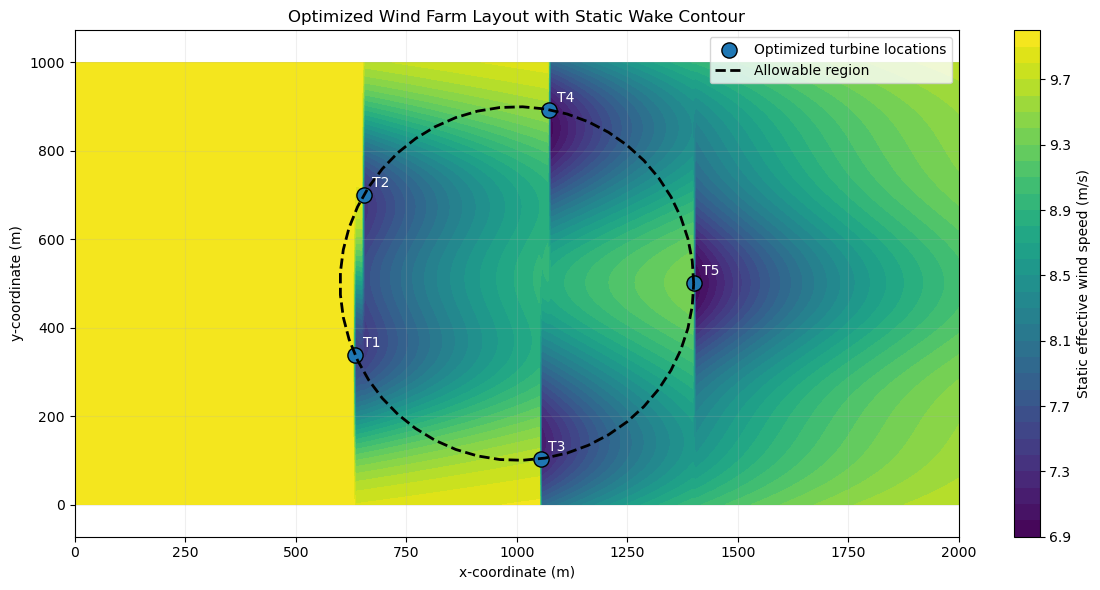

In [7]:
# ------------------------------------------------------------
# Construct a spatial grid
# ------------------------------------------------------------
nx = 300
ny = 180

x_grid = np.linspace(0.0, Lx, nx)
y_grid = np.linspace(0.0, Ly, ny)
X, Y = np.meshgrid(x_grid, y_grid)

# Begin with free-stream wind everywhere
V_field = np.full_like(X, v0, dtype=float)

# ------------------------------------------------------------
# Superimpose downstream wake deficits from all turbines
# ------------------------------------------------------------
for _, row in df.iterrows():
    x_t = row["x (m)"]
    y_t = row["y (m)"]

    dx = X - x_t
    dy = Y - y_t

    # Wake exists only downstream of the turbine.
    downstream = dx > 0.0

    deficit = np.zeros_like(X)
    deficit[downstream] = (
        a * v0
        * np.exp(-kx * dx[downstream])
        * np.exp(-(dy[downstream]**2) / (2.0 * sigma_y**2))
    )

    V_field -= deficit

# Keep the plotted field nonnegative for readability.
V_field = np.maximum(V_field, 0.0)

# ------------------------------------------------------------
# Plot wind-speed contour + optimized turbine positions
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

contour = plt.contourf(X, Y, V_field, levels=30)
cbar = plt.colorbar(contour)
cbar.set_label("Static effective wind speed (m/s)")

plt.scatter(df["x (m)"], df["y (m)"],
    s=120, edgecolors="black", label="Optimized turbine locations")

for _, row in df.iterrows():
    plt.text(row["x (m)"] + 18, row["y (m)"] + 18, f"T{int(row['Turbine'])}",
        fontsize=10, color='w')

# Plot the circular siting region
th = np.linspace(0,2*np.pi)
plt.plot(xc + R*np.cos(th), yc + R*np.sin(th), 
         'k--', linewidth=2, label="Allowable region")

plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.xlabel("x-coordinate (m)")
plt.ylabel("y-coordinate (m)")
plt.title("Optimized Wind Farm Layout with Static Wake Contour")
plt.legend(loc="upper right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.axis('equal')
plt.show()

## Plot turbine wind speeds and generated power

The optimized effective wind speeds show how much each turbine is affected by upstream wakes. The corresponding power follows the cubic approximation $P_i=K_Pv_i^3$.

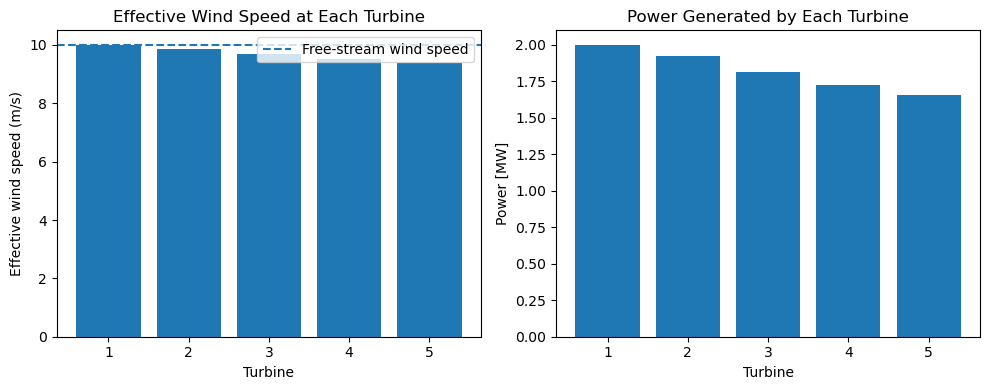

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(df["Turbine"], df["Wind Speed (m/s)"])

ax[0].axhline(v0, linestyle="--", linewidth=1.5,
    label="Free-stream wind speed")

ax[0].set_xlabel("Turbine")
ax[0].set_ylabel("Effective wind speed (m/s)")
ax[0].set_title("Effective Wind Speed at Each Turbine")
ax[0].set_xticks(df["Turbine"])
ax[0].legend()


ax[1].bar(df["Turbine"], df["Power"])
ax[1].set_xlabel("Turbine")
ax[1].set_ylabel("Power [MW]")
ax[1].set_title("Power Generated by Each Turbine")
ax[1].set_xticks(df["Turbine"])

plt.tight_layout()
plt.show()

## Notes and possible extensions

This notebook is intentionally simplified for introducing nonlinear optimization in wind-energy systems.

Possible extensions include:

- varying wind direction and wind speed;
- multiple wind scenarios with probabilities;
- Jensen/Park or Gaussian/Bastankhah wake models;
- realistic turbine power curves with cut-in, rated, and cut-out speeds;
- terrain or exclusion-zone constraints;
- economic objectives such as annual energy production or levelized cost;
- mixed-integer formulations when candidate turbine sites are discrete.

## Now, we try to add an ambient wind speed field in the domain

In [9]:
# ============================================================
# SPATIALLY VARYING AMBIENT WIND FIELD
# ============================================================

v_base = 7.0       # Background wind speed [m/s]
A_wind = 5.0       # Additional wind speed at hotspot [m/s]

x_hot = 1250.0     # Center of high-wind region [m]
y_hot = 650.0

sigma_hot = 450.0  # Spatial spread [m]

def ambient_wind_pyomo(x, y):
    return v_base + A_wind * pyo.exp(-((x - x_hot)**2 + (y - y_hot)**2)/ (2 * sigma_hot**2))

# Delete the old wind speed rule
model.del_component(model.wind_speed)

# Define the new wind speed rule (spatial)
def wind_speed_rule_spatial(model, i):

    # Ambient wind at turbine i
    v_ambient_i = ambient_wind_pyomo(model.x[i], model.y[i])

    # First turbine has no upstream turbine
    if i == 1:
        return model.v[i] == v_ambient_i

    # Wake deficits from all upstream turbines j < i
    wake_deficit = sum(a * ambient_wind_pyomo(model.x[j], model.y[j])
        * pyo.exp(-kx * (model.x[i] - model.x[j]))
        * pyo.exp(-(model.y[i] - model.y[j])**2 / (2 * sigma_y**2))
        for j in range(1, i)
    )
    return model.v[i] == v_ambient_i - wake_deficit

# Recreate constraint using the same component name
model.wind_speed = pyo.Constraint(
    model.I,
    rule=wind_speed_rule_spatial
)

# Setup a new variable bounds for v
for i in model.I:
    model.v[i].setlb(1.0)
    model.v[i].setub(12.0)

### Solve the NLP again

In [10]:
solver = pyo.SolverFactory("ipopt")
results = solver.solve(model, tee=True)

print("Solver status:", results.solver.status)
print("Termination condition:", results.solver.termination_condition)

# Store results
results_data = []

for i in model.I:
    x_i = pyo.value(model.x[i])
    y_i = pyo.value(model.y[i])
    v_ambient_i = pyo.value(ambient_wind_pyomo(model.x[i], model.y[i]))
    v_effective_i = pyo.value(model.v[i])
    P_i = Kp * v_effective_i**3

    results_data.append([i, x_i, y_i, v_ambient_i, v_effective_i, P_i])


df_spatial = pd.DataFrame(
    results_data,
    columns=[
        "Turbine",
        "x (m)",
        "y (m)",
        "Ambient Wind Speed (m/s)",
        "Effective Wind Speed (m/s)",
        "Power (MW)"
    ]
)

display(df_spatial)

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:       35
Number of nonzeros in inequality constraint Jacobian.:       58
Number of nonzeros in Lagrangian Hessian.............:       60

Total number of variables............................:       15
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       15
                     variables with only upper bounds:        0
Total number of equality constraints.................:        5
Total number

,Turbine,x (m),y (m),Ambient Wind Speed (m/s),Effective Wind Speed (m/s),Power (MW)
0,1,971.455994,343.895743,10.275623,10.275623,2.169974
1,2,991.456002,643.228368,11.238779,10.901765,2.591317
2,3,1206.430340,157.382848,9.733441,8.982628,1.449574
3,4,1226.430344,829.741261,11.610314,10.791431,2.513432
4,5,1399.165482,525.824046,11.555911,9.772495,1.866579


## Plot the new results

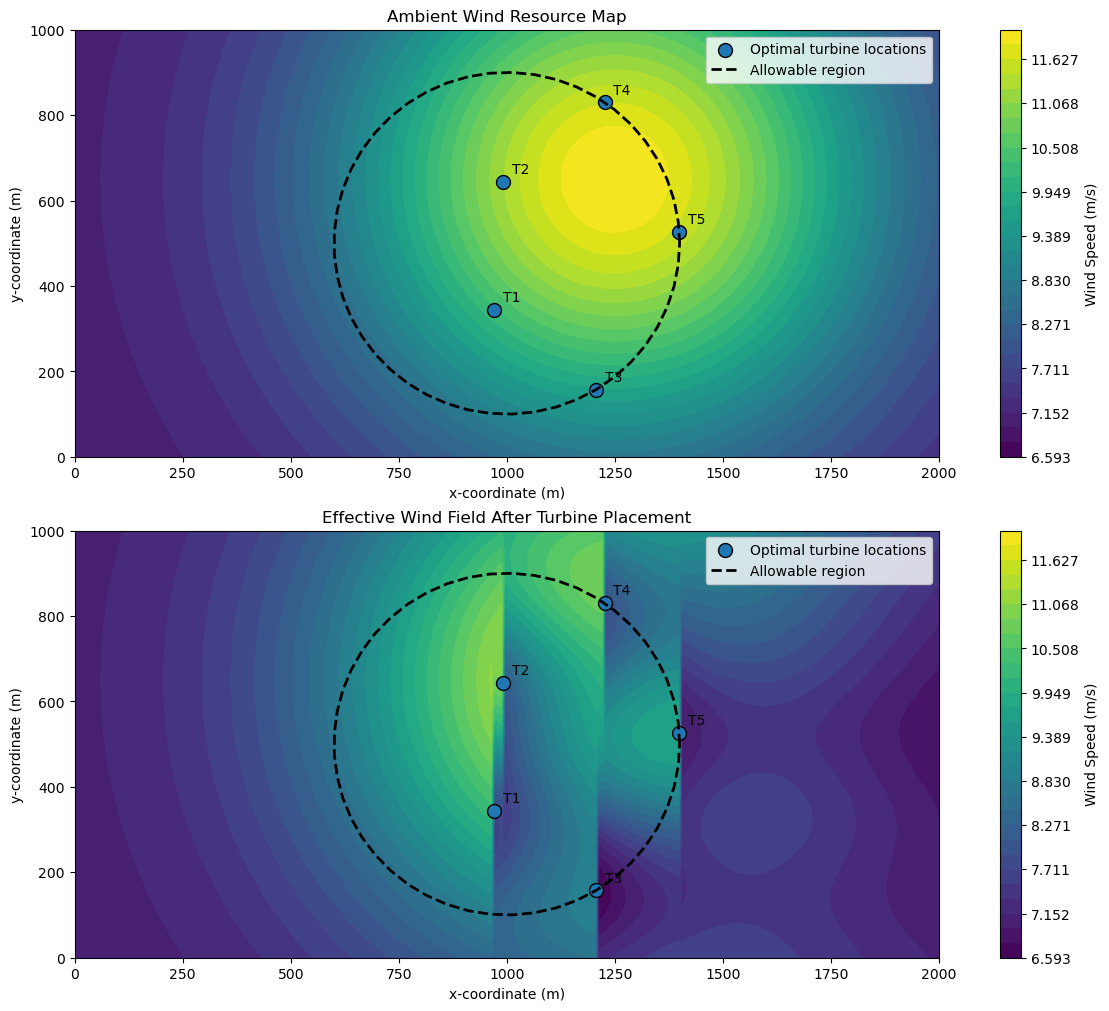

In [11]:
# ============================================================
# NUMERICAL AMBIENT WIND FUNCTION FOR PLOTTING
# ============================================================

def ambient_wind_numpy(x, y):
    return v_base + A_wind * np.exp(-((x - x_hot)**2 + (y - y_hot)**2) / (2 * sigma_hot**2))

# Spatial grid
nx = 250
ny = 150

x_grid = np.linspace(0, Lx, nx)
y_grid = np.linspace(0, Ly, ny)

X, Y = np.meshgrid(x_grid, y_grid)

# Ambient wind resource
V_ambient = ambient_wind_numpy(X, Y)
V_effective = V_ambient.copy()

for _, row in df_spatial.iterrows():

    x_t = row["x (m)"]
    y_t = row["y (m)"]

    # Ambient wind at the turbine generating the wake
    v_source = ambient_wind_numpy(x_t, y_t)

    # Downstream distance
    dx = X - x_t

    # Lateral distance
    dy = Y - y_t

    # Wake deficit
    wake = a * v_source * np.exp(-kx * dx) * np.exp(-(dy**2) / (2 * sigma_y**2))
    
    # Wake only exists downstream
    wake = np.where(dx > 0, wake, 0.0)

    V_effective -= wake

V_effective = np.maximum(V_effective, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(11, 10), constrained_layout=True)

# Use same contour levels in both plots
vmin = min(V_ambient.min(), V_effective.min())
vmax = max(V_ambient.max(), V_effective.max())
levels = np.linspace(vmin, vmax, 30)

# AMBIENT WIND RESOURCE
contour1 = axes[0].contourf(X, Y, V_ambient, levels=levels)

axes[0].scatter(df_spatial["x (m)"], df_spatial["y (m)"],
    s=100, edgecolors="black", label="Optimal turbine locations")

for _, row in df_spatial.iterrows():
    axes[0].text(row["x (m)"] + 20, row["y (m)"] + 20,
        f"T{int(row['Turbine'])}")

# Circular allowable region
th = np.linspace(0, 2*np.pi)
axes[0].plot(xc + R*np.cos(th), yc + R*np.sin(th),
    "k--", linewidth=2, label="Allowable region")

axes[0].set_xlim(0, Lx)
axes[0].set_ylim(0, Ly)
axes[0].set_xlabel("x-coordinate (m)")
axes[0].set_ylabel("y-coordinate (m)")
axes[0].set_title("Ambient Wind Resource Map")
axes[0].legend()
fig.colorbar(contour1, ax=axes[0], label="Wind Speed (m/s)")


# EFFECTIVE WIND FIELD
contour2 = axes[1].contourf(X, Y, V_effective, levels=levels)

axes[1].scatter(df_spatial["x (m)"], df_spatial["y (m)"],
    s=100, edgecolors="black", label="Optimal turbine locations")

for _, row in df_spatial.iterrows():
    axes[1].text(row["x (m)"] + 20, row["y (m)"] + 20,
        f"T{int(row['Turbine'])}")

axes[1].plot(xc + R*np.cos(th), yc + R*np.sin(th),
    "k--", linewidth=2, label="Allowable region")

axes[1].set_xlim(0, Lx)
axes[1].set_ylim(0, Ly)
axes[1].set_xlabel("x-coordinate (m)")
axes[1].set_ylabel("y-coordinate (m)")
axes[1].set_title("Effective Wind Field After Turbine Placement")
axes[1].legend()

fig.colorbar(contour2, ax=axes[1], label="Wind Speed (m/s)")
plt.show()